<a href="https://colab.research.google.com/github/ehdrb1023/GraduationProject/blob/main/Muon_Lion_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. 구글 드라이브 연동 + CIFAR-10 준비 (베이스라인과 동일)
from google.colab import drive
import os
import urllib.request

drive.mount('/content/drive')

drive_data_path = '/content/drive/MyDrive/Colab_Data'
os.makedirs(drive_data_path, exist_ok=True)

cifar_url = 'https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz'
destination_path = os.path.join(drive_data_path, 'cifar10.tgz')

if not os.path.exists(destination_path):
    print("🚀 CIFAR-10 다운로드 시작...")
    urllib.request.urlretrieve(cifar_url, destination_path)
    print(f"✅ 다운로드 완료: {destination_path}")
else:
    print("✨ 이미 구글 드라이브에 cifar10.tgz 파일이 존재합니다!")

Mounted at /content/drive
✨ 이미 구글 드라이브에 cifar10.tgz 파일이 존재합니다!


In [ ]:
import os, time, json, tarfile
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ 현재 사용 중인 장치: {device}", torch.cuda.get_device_name(0) if device.type == 'cuda' else '')

drive_zip_path = '/content/drive/MyDrive/Colab_Data/cifar10.tgz'
local_data_path = '/content/cifar10'
if not os.path.exists(local_data_path):
    print("📦 로컬로 압축 해제 중...")
    with tarfile.open(drive_zip_path, 'r:gz') as tar:
        tar.extractall(path='/content/')
    print("✅ 로컬 압축 해제 완료!")

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_dataset = datasets.ImageFolder(root=os.path.join(local_data_path, 'train'), transform=transform_train)
test_dataset  = datasets.ImageFolder(root=os.path.join(local_data_path, 'test'),  transform=transform_test)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=2)
print(f"📊 학습 {len(train_dataset)}장 | 테스트 {len(test_dataset)}장")

🖥️ 현재 사용 중인 장치: cuda Tesla T4
📦 로컬로 압축 해제 중...


/tmp/ipykernel_2145/1031193267.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='/content/')


✅ 로컬 압축 해제 완료!
📊 학습 50000장 | 테스트 10000장


In [ ]:
# ---------------------------------------------------------
# 모델 (베이스라인과 동일)
# ---------------------------------------------------------
def get_resnet18_model():
    model = models.resnet18(num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.to(device)

# ---------------------------------------------------------
# Lion (Chen et al., 2023) — 부호(sign)만 사용하는 업데이트
# ---------------------------------------------------------
class Lion(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-4, betas=(0.9, 0.99), weight_decay=0.0):
        super().__init__(params, dict(lr=lr, betas=betas, weight_decay=weight_decay))

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr, wd = group['lr'], group['weight_decay']
            beta1, beta2 = group['betas']
            for p in group['params']:
                if p.grad is None:
                    continue
                g = p.grad
                state = self.state[p]
                if 'exp_avg' not in state:
                    state['exp_avg'] = torch.zeros_like(p)
                m = state['exp_avg']
                update = (m * beta1 + g * (1 - beta1)).sign_()
                p.mul_(1 - lr * wd)              # decoupled weight decay
                p.add_(update, alpha=-lr)
                m.mul_(beta2).add_(g, alpha=1 - beta2)

# ---------------------------------------------------------
# Muon (Jordan, 2024) — 2D 이상 가중치의 모멘텀을 Newton-Schulz로 직교화
#   conv 커널 (out, in, kh, kw) → (out, in*kh*kw)로 reshape
#   BN·bias·마지막 fc는 내부 AdamW가 담당 (표준 구성)
# ---------------------------------------------------------
def zeropower_via_newtonschulz5(G, steps=5):
    a, b, c = (3.4445, -4.7750, 2.0315)
    X = G.float()   # T4는 bfloat16 가속이 없어서 float32 사용
    transpose = X.size(0) > X.size(1)
    if transpose:
        X = X.T
    X = X / (X.norm() + 1e-7)
    for _ in range(steps):
        A = X @ X.T
        B = b * A + c * (A @ A)
        X = a * X + B @ X
    if transpose:
        X = X.T
    return X

class Muon(torch.optim.Optimizer):
    """param_groups마다 use_muon 플래그. 스케줄러 하나로 두 그룹의 lr을 함께 조절."""
    def __init__(self, param_groups):
        for g in param_groups:
            if g['use_muon']:
                g.setdefault('momentum', 0.95); g.setdefault('nesterov', True)
                g.setdefault('ns_steps', 5);    g.setdefault('weight_decay', 0.0)
            else:
                g.setdefault('betas', (0.9, 0.999)); g.setdefault('eps', 1e-8)
                g.setdefault('weight_decay', 0.0)
        super().__init__(param_groups, dict())

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr, wd = group['lr'], group['weight_decay']
            if group['use_muon']:
                mom = group['momentum']
                for p in group['params']:
                    if p.grad is None:
                        continue
                    state = self.state[p]
                    if 'momentum_buffer' not in state:
                        state['momentum_buffer'] = torch.zeros_like(p)
                    buf = state['momentum_buffer']
                    buf.lerp_(p.grad, 1 - mom)
                    g = p.grad.lerp(buf, mom) if group['nesterov'] else buf
                    g2d = g.reshape(g.size(0), -1)
                    u = zeropower_via_newtonschulz5(g2d, group['ns_steps'])
                    u = u * max(1.0, g2d.size(0) / g2d.size(1)) ** 0.5
                    p.mul_(1 - lr * wd)
                    p.add_(u.view_as(p).to(p.dtype), alpha=-lr)
            else:
                beta1, beta2 = group['betas']
                for p in group['params']:
                    if p.grad is None:
                        continue
                    state = self.state[p]
                    if 'step' not in state:
                        state['step'] = 0
                        state['exp_avg'] = torch.zeros_like(p)
                        state['exp_avg_sq'] = torch.zeros_like(p)
                    state['step'] += 1
                    t = state['step']
                    m, v = state['exp_avg'], state['exp_avg_sq']
                    m.lerp_(p.grad, 1 - beta1)
                    v.mul_(beta2).addcmul_(p.grad, p.grad, value=1 - beta2)
                    m_hat = m / (1 - beta1 ** t)
                    v_hat = v / (1 - beta2 ** t)
                    p.mul_(1 - lr * wd)
                    p.addcdiv_(m_hat, v_hat.sqrt().add_(group['eps']), value=-lr)

def build_optimizer(optimizer_name, model):
    if optimizer_name == 'Lion':
        return Lion(model.parameters(), lr=3e-4, betas=(0.9, 0.99), weight_decay=0.03)
    elif optimizer_name == 'Muon':
        muon_params, adam_params = [], []
        for name, p in model.named_parameters():
            if p.ndim >= 2 and not name.startswith('fc.'):
                muon_params.append(p)
            else:
                adam_params.append(p)
        print(f"   Muon 대상 텐서 {len(muon_params)}개 / AdamW 대상 텐서 {len(adam_params)}개")
        return Muon([
            dict(params=muon_params, use_muon=True,  lr=0.02, momentum=0.95, weight_decay=5e-4),
            dict(params=adam_params, use_muon=False, lr=1e-3, betas=(0.9, 0.999), weight_decay=0.01),
        ])
    raise ValueError("Unsupported optimizer")

In [ ]:
# ---------------------------------------------------------
# ⏱️ 소요 시간 미리 측정 (약 1~2분) — 50 step 측정 후 1 epoch / 50 epoch로 환산
# ---------------------------------------------------------
def estimate_time(optimizer_name, n_warmup=10, n_measure=50):
    model = get_resnet18_model()
    optimizer = build_optimizer(optimizer_name, model)
    criterion = nn.CrossEntropyLoss()
    model.train()
    it = iter(train_loader)
    for i in range(n_warmup + n_measure):
        if i == n_warmup:
            torch.cuda.synchronize(); t0 = time.time()
        images, labels = next(it)
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
    torch.cuda.synchronize()
    step_time = (time.time() - t0) / n_measure

    model.eval(); t0 = time.time()
    with torch.no_grad():
        for images, labels in test_loader:
            model(images.to(device))
    torch.cuda.synchronize()
    eval_time = time.time() - t0

    epoch_time = step_time * len(train_loader) + eval_time
    print(f"[{optimizer_name}] step {step_time*1000:.1f}ms | epoch ≈ {epoch_time:.1f}s | 50 epoch ≈ {epoch_time*50/60:.1f}분")
    del model, optimizer
    torch.cuda.empty_cache()
    return epoch_time

est = {name: estimate_time(name) for name in ['Lion', 'Muon']}
print(f"\n👉 전체 예상 소요: {sum(est.values())*50/60:.0f}분")

[Lion] step 110.5ms | epoch ≈ 48.8s | 50 epoch ≈ 40.7분
   Muon 대상 텐서 20개 / AdamW 대상 텐서 42개
[Muon] step 129.2ms | epoch ≈ 55.7s | 50 epoch ≈ 46.4분

👉 전체 예상 소요: 87분


In [ ]:
# ---------------------------------------------------------
# 학습 엔진 (베이스라인 train_optimizer와 동일 루프 + 체크포인트 재개 + epoch 시간 기록)
# ---------------------------------------------------------
def train_optimizer(optimizer_name, num_epochs=50):
    model = get_resnet18_model()
    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(optimizer_name, model)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': [], 'epoch_time': []}
    ckpt_path = os.path.join(drive_data_path, f'ckpt_{optimizer_name}.pt')
    start_epoch = 0
    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model'])
        optimizer.load_state_dict(ckpt['optimizer'])
        scheduler.load_state_dict(ckpt['scheduler'])
        history = ckpt['history']
        start_epoch = ckpt['epoch']
        print(f"♻️ [{optimizer_name}] 체크포인트 발견 → {start_epoch} epoch부터 재개")

    print(f"\n🔥 [{optimizer_name}] 학습 시작 (총 {num_epochs} Epoch) 🔥")

    for epoch in range(start_epoch, num_epochs):
        start_time = time.time()

        # --- 1. Train ---
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        epoch_train_loss = train_loss / len(train_loader)
        epoch_train_acc = 100. * train_correct / train_total
        scheduler.step()

        # --- 2. Test ---
        model.eval()
        test_loss, test_correct, test_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()

        epoch_test_loss = test_loss / len(test_loader)
        epoch_test_acc = 100. * test_correct / test_total
        elapsed_time = time.time() - start_time

        history['train_loss'].append(epoch_train_loss)
        history['test_loss'].append(epoch_test_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_acc'].append(epoch_test_acc)
        history['epoch_time'].append(elapsed_time)

        print(f"Epoch [{epoch+1}/{num_epochs}] | Time: {elapsed_time:.1f}s | "
              f"Train Acc: {epoch_train_acc:.2f}% | Test Acc: {epoch_test_acc:.2f}%")

        torch.save({'model': model.state_dict(), 'optimizer': optimizer.state_dict(),
                    'scheduler': scheduler.state_dict(), 'history': history, 'epoch': epoch + 1},
                   ckpt_path)

    torch.save(model.state_dict(), f"{optimizer_name}_best_model.pth")
    with open(os.path.join(drive_data_path, f'history_{optimizer_name}.json'), 'w') as f:
        json.dump(history, f)
    return history

In [ ]:
history_lion = train_optimizer('Lion', num_epochs=50)
print("\n✅ Lion 50 Epoch 학습 및 평가 완료!")

♻️ [Lion] 체크포인트 발견 → 29 epoch부터 재개

🔥 [Lion] 학습 시작 (총 50 Epoch) 🔥
Epoch [30/50] | Time: 46.7s | Train Acc: 98.74% | Test Acc: 91.81%
Epoch [31/50] | Time: 49.0s | Train Acc: 98.90% | Test Acc: 92.05%
Epoch [32/50] | Time: 51.6s | Train Acc: 98.91% | Test Acc: 91.87%
Epoch [33/50] | Time: 51.6s | Train Acc: 99.15% | Test Acc: 91.73%
Epoch [34/50] | Time: 51.5s | Train Acc: 99.25% | Test Acc: 92.16%
Epoch [35/50] | Time: 51.6s | Train Acc: 99.31% | Test Acc: 91.87%
Epoch [36/50] | Time: 50.8s | Train Acc: 99.39% | Test Acc: 91.89%
Epoch [37/50] | Time: 50.7s | Train Acc: 99.48% | Test Acc: 92.50%
Epoch [38/50] | Time: 50.0s | Train Acc: 99.57% | Test Acc: 92.52%
Epoch [39/50] | Time: 51.3s | Train Acc: 99.65% | Test Acc: 92.68%
Epoch [40/50] | Time: 50.5s | Train Acc: 99.73% | Test Acc: 92.33%
Epoch [41/50] | Time: 50.9s | Train Acc: 99.76% | Test Acc: 92.71%
Epoch [42/50] | Time: 49.7s | Train Acc: 99.82% | Test Acc: 92.48%
Epoch [43/50] | Time: 50.9s | Train Acc: 99.82% | Test Acc: 92.

In [ ]:
history_muon = train_optimizer('Muon', num_epochs=50)
print("\n✅ Muon 50 Epoch 학습 및 평가 완료!")

   Muon 대상 텐서 20개 / AdamW 대상 텐서 42개

🔥 [Muon] 학습 시작 (총 50 Epoch) 🔥
Epoch [1/50] | Time: 65.0s | Train Acc: 62.32% | Test Acc: 76.23%
Epoch [2/50] | Time: 64.3s | Train Acc: 80.92% | Test Acc: 81.85%
Epoch [3/50] | Time: 67.6s | Train Acc: 85.52% | Test Acc: 84.03%
Epoch [4/50] | Time: 64.3s | Train Acc: 88.57% | Test Acc: 86.76%
Epoch [5/50] | Time: 65.3s | Train Acc: 90.30% | Test Acc: 88.33%
Epoch [6/50] | Time: 64.0s | Train Acc: 91.55% | Test Acc: 89.37%
Epoch [7/50] | Time: 64.8s | Train Acc: 92.77% | Test Acc: 88.96%
Epoch [8/50] | Time: 64.3s | Train Acc: 93.67% | Test Acc: 90.50%
Epoch [9/50] | Time: 64.9s | Train Acc: 94.56% | Test Acc: 91.01%
Epoch [10/50] | Time: 64.0s | Train Acc: 95.29% | Test Acc: 91.66%
Epoch [11/50] | Time: 65.0s | Train Acc: 95.86% | Test Acc: 90.21%
Epoch [12/50] | Time: 64.2s | Train Acc: 96.09% | Test Acc: 91.42%
Epoch [13/50] | Time: 64.8s | Train Acc: 96.71% | Test Acc: 91.31%
Epoch [14/50] | Time: 64.2s | Train Acc: 96.89% | Test Acc: 92.05%
Epoc

In [ ]:
import pandas as pd

epochs = range(1, 51)
data = {'Epoch': epochs}
for name, h in [('Lion', history_lion), ('Muon', history_muon)]:
    data[f'{name}_Train_Loss'] = h['train_loss']
    data[f'{name}_Test_Loss']  = h['test_loss']
    data[f'{name}_Train_Acc']  = h['train_acc']
    data[f'{name}_Test_Acc']   = h['test_acc']
    data[f'{name}_Epoch_Time'] = h['epoch_time']

df_new = pd.DataFrame(data)
save_path = '/content/drive/MyDrive/Colab_Data/optimizer_results_lion_muon.csv'
df_new.to_csv(save_path, index=False)
print(f"✅ 저장 완료: {save_path}")

✅ 저장 완료: /content/drive/MyDrive/Colab_Data/optimizer_results_lion_muon.csv


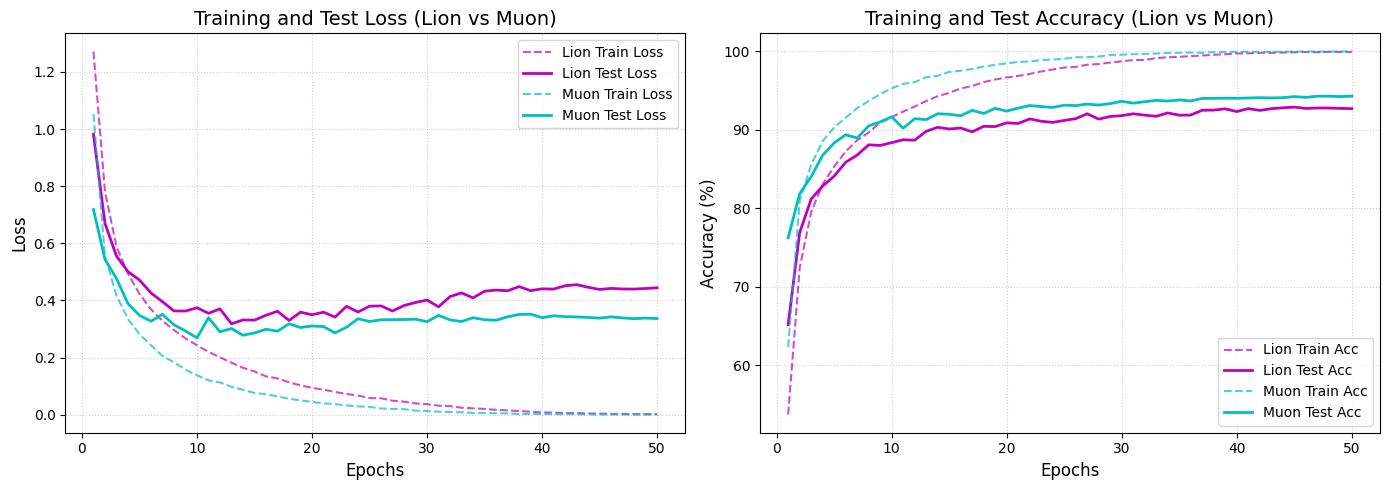

In [ ]:
# ---------------------------------------------------------
# 그래프 1: Lion vs Muon (베이스라인 셀과 같은 형식)
# ---------------------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
epochs = range(1, len(history_lion['train_loss']) + 1)

plt.subplot(1, 2, 1)
plt.plot(epochs, history_lion['train_loss'], 'm--', alpha=0.7, label='Lion Train Loss')
plt.plot(epochs, history_lion['test_loss'],  'm-',  linewidth=2, label='Lion Test Loss')
plt.plot(epochs, history_muon['train_loss'], 'c--', alpha=0.7, label='Muon Train Loss')
plt.plot(epochs, history_muon['test_loss'],  'c-',  linewidth=2, label='Muon Test Loss')
plt.title('Training and Test Loss (Lion vs Muon)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(epochs, history_lion['train_acc'], 'm--', alpha=0.7, label='Lion Train Acc')
plt.plot(epochs, history_lion['test_acc'],  'm-',  linewidth=2, label='Lion Test Acc')
plt.plot(epochs, history_muon['train_acc'], 'c--', alpha=0.7, label='Muon Train Acc')
plt.plot(epochs, history_muon['test_acc'],  'c-',  linewidth=2, label='Muon Test Acc')
plt.title('Training and Test Accuracy (Lion vs Muon)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

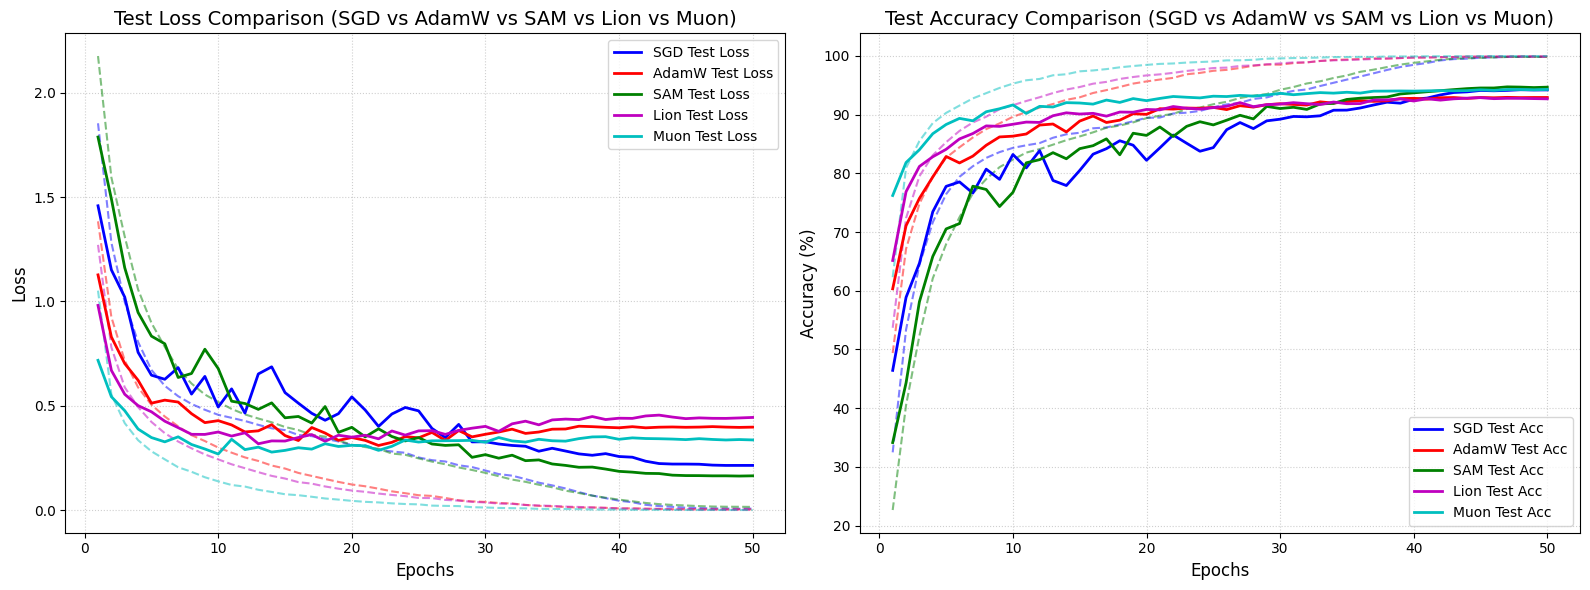

Optimizer  Final Test Acc  Best Test Acc  Final Test Loss
      SGD           94.22          94.25           0.2143
    AdamW           92.93          92.95           0.3978
      SAM           94.69          94.74           0.1644
     Lion           92.70          92.90           0.4442
     Muon           94.30          94.30           0.3365
Lion 평균 epoch 시간: 49.2s
Muon 평균 epoch 시간: 64.8s


In [ ]:
# ---------------------------------------------------------
# 그래프 2: 기존 결과(SGD/AdamW/SAM) CSV를 불러와 5종 비교 (베이스라인 마지막 셀과 같은 형식)
# ---------------------------------------------------------
old_path = '/content/drive/MyDrive/Colab_Data/optimizer_results.csv'
df_old = pd.read_csv(old_path)

def hist_from_df(df, name):
    return {'train_loss': df[f'{name}_Train_Loss'].tolist(), 'test_loss': df[f'{name}_Test_Loss'].tolist(),
            'train_acc':  df[f'{name}_Train_Acc'].tolist(),  'test_acc':  df[f'{name}_Test_Acc'].tolist()}

all_hist = {
    'SGD':   (hist_from_df(df_old, 'SGD'),   'b'),
    'AdamW': (hist_from_df(df_old, 'AdamW'), 'r'),
    'SAM':   (hist_from_df(df_old, 'SAM'),   'g'),
    'Lion':  (history_lion, 'm'),
    'Muon':  (history_muon, 'c'),
}

plt.figure(figsize=(16, 6))
epochs = range(1, 51)

plt.subplot(1, 2, 1)
for name, (h, c) in all_hist.items():
    plt.plot(epochs, h['train_loss'], f'{c}--', alpha=0.5)
for name, (h, c) in all_hist.items():
    plt.plot(epochs, h['test_loss'], f'{c}-', linewidth=2, label=f'{name} Test Loss')
plt.title('Test Loss Comparison (SGD vs AdamW vs SAM vs Lion vs Muon)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.subplot(1, 2, 2)
for name, (h, c) in all_hist.items():
    plt.plot(epochs, h['train_acc'], f'{c}--', alpha=0.5)
for name, (h, c) in all_hist.items():
    plt.plot(epochs, h['test_acc'], f'{c}-', linewidth=2, label=f'{name} Test Acc')
plt.title('Test Accuracy Comparison (SGD vs AdamW vs SAM vs Lion vs Muon)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 요약 표
rows = []
for name, (h, _) in all_hist.items():
    rows.append({'Optimizer': name, 'Final Test Acc': round(h['test_acc'][-1], 2),
                 'Best Test Acc': round(max(h['test_acc']), 2), 'Final Test Loss': round(h['test_loss'][-1], 4)})
print(pd.DataFrame(rows).to_string(index=False))
for name, h in [('Lion', history_lion), ('Muon', history_muon)]:
    print(f"{name} 평균 epoch 시간: {sum(h['epoch_time'])/len(h['epoch_time']):.1f}s")